<div style="display: flex; align-items: center; justify-content: center; gap: 20px;">
    <img src="https://purepng.com/public/uploads/large/purepng.com-walmart-logologobrand-logoiconslogos-2515199386533ogay.png" alt="Image Gauche" style="width: 400px; height: auto;">
    <div style="font-size: 26px; text-align: center;">
        <h1>
            <span style="font-weight: bold; color:#0071ce; text-decoration: underline;">
                Walmart Project 2
            </span>
        </h1>
    </div>
    <img src="https://purepng.com/public/uploads/large/purepng.com-walmart-logologobrand-logoiconslogos-2515199386533ogay.png" alt="Image Droite" style="width: 400px; height: auto;">
</div>

<h1 style="font-size: 18px; text-align: center; font-style: italic;">
    <span style="font-weight: bold; color:#0071ce">
        Student : Loic VALENTINI
    </span>
</h1>

# **1. Import of libraires and dataset**

In [106]:
# Libraries to import

import pandas as pd
import numpy as np

import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from sklearn.preprocessing import  OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import r2_score


import warnings
warnings.filterwarnings("ignore")

In [107]:
# Dataset import from csv + copy to avoid re-import

dataset_walmart_ML = pd.read_csv("Walmart_simplified_dataset.csv")
dataset = dataset_walmart_ML

In [108]:
# Quick visualisation of dataset

dataset.head()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Day,WeekNumber
0,6.0,1572117.54,0.0,59.61,3.045,214.777523,6.858,2011.0,2.0,18.0,7
1,13.0,1807545.43,0.0,42.38,3.435,128.616064,7.470,2011.0,3.0,25.0,12
2,6.0,1644470.66,0.0,78.89,2.759,212.412888,7.092,2010.0,5.0,28.0,21
3,4.0,1857533.70,0.0,NaN,2.756,126.160226,7.896,2010.0,5.0,28.0,21
4,15.0,695396.19,0.0,69.80,4.069,134.855161,7.658,2011.0,6.0,3.0,22


# **2. Variables definition**

In [109]:
# Some necessary variables

target_name = "Weekly_Sales"
numeric_features = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month','Day','WeekNumber']
categorical_features = ['Store', 'Holiday_Flag']

In [110]:
# Split of dataset into X (features) and Y (target)

Y = dataset.loc[:, target_name]
X = dataset.drop([target_name], axis=1)

print(Y.head(2))
print()
print(X.head(2))
print()

0    1572117.54
1    1807545.43
Name: Weekly_Sales, dtype: float64

   Store  Holiday_Flag  Temperature  Fuel_Price         CPI  Unemployment  \
0    6.0           0.0        59.61       3.045  214.777523         6.858   
1   13.0           0.0        42.38       3.435  128.616064         7.470   

     Year  Month   Day  WeekNumber  
0  2011.0    2.0  18.0           7  
1  2011.0    3.0  25.0          12  



# **3. Complete preprocessing**

In [111]:
# Divide X and Y Train set & Test set 

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)


In [112]:
# Preprocessing pipelines 

numeric_transformer = Pipeline(steps=[
                                        ('imputer', KNNImputer()),  # KNN Imputer could be more precise.
                                        ('scaler', StandardScaler())
                                    ])


categorical_transformer = Pipeline(steps=[
                                        ('encoder', OneHotEncoder(drop='first'))
                                    ])


preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [113]:
# Preprocessings on train and test set

X_train = preprocessor.fit_transform(X_train)
print("X_train")
print(X_train[0:2])
print()

X_test = preprocessor.transform(X_test)
print("X_test")
print(X_test[0:2])

X_train
[[ 1.47174994 -1.35279142  1.00112127 -0.4097767  -1.05558715 -0.02760328
   1.01737744  0.04749535  0.          0.          0.          0.
   0.          0.          0.          1.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.        ]
 [-0.41220244 -0.86832383 -1.11865024  2.07503039 -1.05558715  1.2145443
  -0.16105203  1.18738386  0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          1.
   0.          0.          0.        ]]

X_test
[[ 0.17867354 -0.42821193  0.94082735 -0.66248705 -1.05558715  1.5250812
  -0.51458087  1.47235599  0.          0.          0.          1.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.        ]
 [ 0.31397557  0.97480622  1.16411087 -0.04299423  1

# **4. Base model : predictions, metrics and coefficients**

In [114]:
# Definition of the base model

base_model = LinearRegression()

In [115]:
# Model training

base_model.fit(X_train, Y_train)


LinearRegression()

In [116]:
# Predictions on training and testing sets

Y_train_pred = base_model.predict(X_train)
print("Y_train :")
print(Y_train_pred[0:5])
print()

Y_test_pred = base_model.predict(X_test)
print("Y_test :")
print(Y_test_pred[0:5])
print()

Y_train :
[ 392963.22469153 1140651.19719089 1409073.95536435 2039853.9444484
 1937539.44584224]

Y_test :
[ 385081.66885108 1443106.98979269 1571358.18431598  872596.03762497
  451590.99188292]



In [117]:
# Metrics measurements : R2 Scoring

print("R2 score on training set : ", r2_score(Y_train, Y_train_pred))
print("R2 score on test set : ", r2_score(Y_test, Y_test_pred))

R2 score on training set :  0.9757738189960375
R2 score on test set :  0.9380538251342069


In [118]:
# Get the names and coefficients of the features

feature_names_out = preprocessor.get_feature_names_out()
feature_names = [fname for fname in feature_names_out]
coefs = pd.DataFrame(index = feature_names, data = base_model.coef_.transpose(), columns=["coefficients"])

In [119]:
# Feature importance into a dataframe

feature_importance = coefs.sort_values(by='coefficients', ascending=False)

# Sorted by importance (using absolute values)

feature_importance_abs = abs(coefs).sort_values(by='coefficients', ascending=False)
feature_importance_abs = feature_importance_abs.transpose()
feature_importance_abs

,cat__Store_5.0,cat__Store_3.0,cat__Store_17.0,cat__Store_16.0,cat__Store_9.0,cat__Store_15.0,num__WeekNumber,cat__Store_7.0,num__Month,cat__Store_8.0,...,cat__Store_11.0,num__CPI,num__Day,num__Unemployment,cat__Store_13.0,cat__Holiday_Flag_1.0,num__Fuel_Price,cat__Store_6.0,num__Temperature,num__Year
coefficients,1.363641e+06,1.214319e+06,1.199605e+06,1.178069e+06,1.175121e+06,1.143617e+06,1.042831e+06,1.003024e+06,977843.032667,728589.463042,...,165953.281977,140886.089144,127973.136673,77782.678876,74754.587298,39873.387139,37429.424905,33446.536169,18125.528708,5642.574873


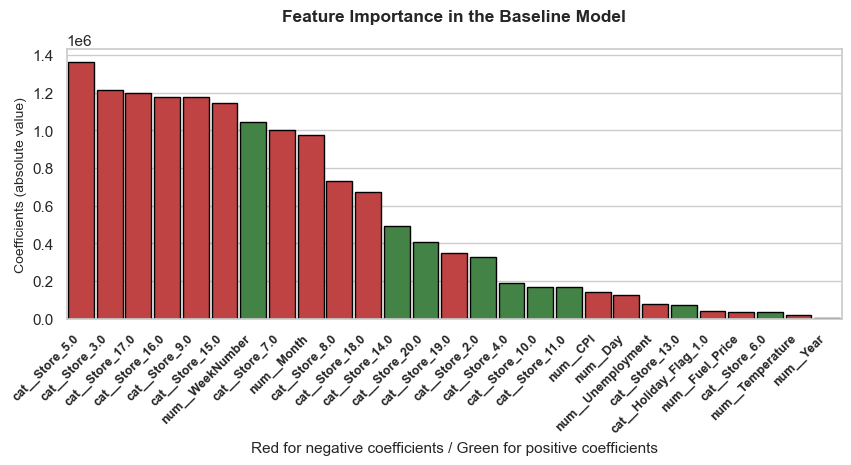

In [120]:
# Plot feature importance


# Colors green for positive importance / red fornegative importance

negative_coefs = feature_importance[feature_importance['coefficients'] < 0]
colors = ['#d32f2f' if y in negative_coefs.index else '#388e3c' for y in feature_importance_abs.columns]


sns.set(rc={'figure.figsize':(10, 3.5)}, style='whitegrid')
sns.barplot(data=feature_importance_abs, orient='v', palette=colors, width=0.9, edgecolor='black')


plt.title('Feature Importance in the Baseline Model', fontsize=12.5, pad=20, fontweight='bold')
plt.xlabel('Red for negative coefficients / Green for positive coefficients', fontsize=11)
plt.ylabel('Coefficients (absolute value)', fontsize=10)
plt.xticks(fontsize=9, fontweight='bold', rotation=45, ha='right')
plt.xticks(feature_importance_abs.columns, fontsize=9, fontweight='bold', rotation=45, ha='right')
plt.legend('', frameon=False)
plt.show()


In [121]:
# Store model results in a model_results dataframe

model_results = pd.DataFrame(columns=['Model_Name', 'R²_Train', 'R²_Test'])

# Creation of update function

def update_model_results(model_results, model_results_dic):
    """
    Updates the DataFrame model_results by adding results of a new model.
    
    :param model_results: DataFrame containing the results of the models.
    :param model_results_dic: Dictionary containing the results of the new model.
    :return: Updated DataFrame with the new model added.
    """
    # Convert dictionnary in dataframe
    new_data = pd.DataFrame([model_results_dic])
    
    # Concatenate model_results with new_data
    model_results = pd.concat([model_results, new_data], ignore_index=True)
    
    return model_results

# Store baseline_results

baseline_dic = {'Model_Name' : 'Baseline_LogisticReg',
                'R²_Train' : round(r2_score(Y_train, Y_train_pred),3),
                'R²_Test' : round(r2_score(Y_test, Y_test_pred),3) }

# Add the results to the model_results DataFrame

model_results = update_model_results(model_results, baseline_dic)

# Display model_results to check the function

model_results


,Model_Name,R²_Train,R²_Test
0,Baseline_LogisticReg,0.976,0.938


##### R² score appears to be very good (0.98 for the training set and 0.93 for the testing set). However, there is slight overfitting, as the training score is higher than the testing score. Therefore, we can try optimizing it using regularization models such as Lasso and Ridge. As expected, the Store and Date features (Month and WeekNumber) have a significant impact on predictions, whereas Temperature, Fuel_Price, and Holiday_Flag are less influential

# **5. Ridge and Lasso models : predictions, metrics and coefficients**

In [122]:
# Application of Ridge model and scoring
ridge = Ridge()
ridge.fit(X_train, Y_train)

# Predictions on training and testing set
Y_train_pred = ridge.predict(X_train)
Y_test_pred = ridge.predict(X_test)

# Print R^2 scores
print("R2 score on training set : ", r2_score(Y_train, Y_train_pred))
print("R2 score on test set : ", r2_score(Y_test, Y_test_pred))

# Store baseline_results
ridge_dic = {'Model_Name' : 'Ridge',
                'R²_Train' : round(r2_score(Y_train, Y_train_pred),3),
                'R²_Test' : round(r2_score(Y_test, Y_test_pred),3) }

# Add the results to the model_results DataFrame
model_results = update_model_results(model_results, ridge_dic)

# Display model_results to check the function
model_results

R2 score on training set :  0.9286857671781328
R2 score on test set :  0.9099675799831036


,Model_Name,R²_Train,R²_Test
0,Baseline_LogisticReg,0.976,0.938
1,Ridge,0.929,0.910


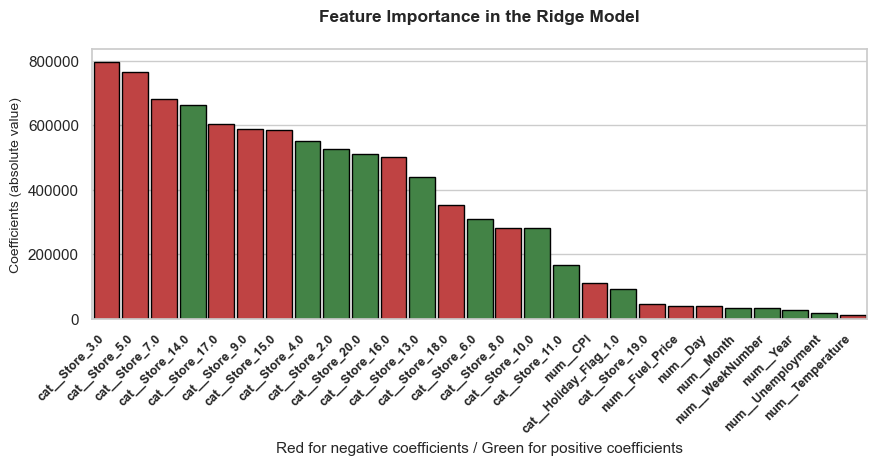

In [123]:
# See the feature importance for Ridge model

# Extarct feature names
feature_names_out = preprocessor.get_feature_names_out()
feature_names = [fname for fname in feature_names_out]
coefs = pd.DataFrame(index = feature_names, data = ridge.coef_.transpose(), columns=["coefficients"])

# Feature importance into a dataframe
feature_importance = coefs.sort_values(by='coefficients', ascending=False)

# Sorted by importance (using absolute values)
feature_importance_abs = abs(coefs).sort_values(by='coefficients', ascending=False)
feature_importance_abs = feature_importance_abs.transpose()
feature_importance_abs

# Colors green for positive importance / red for negative importance
negative_coefs = feature_importance[feature_importance['coefficients'] < 0]
colors = ['#d32f2f' if y in negative_coefs.index else '#388e3c' for y in feature_importance_abs.columns]

# Plot feature importance

sns.set(rc={'figure.figsize':(10, 3.5)}, style='whitegrid')
sns.barplot(data=feature_importance_abs, orient='v', palette=colors, width=0.9, edgecolor='black')

plt.title('Feature Importance in the Ridge Model', fontsize=12.5, pad=20, fontweight='bold')
plt.xlabel('Red for negative coefficients / Green for positive coefficients', fontsize=11)
plt.ylabel('Coefficients (absolute value)', fontsize=10)
plt.xticks(fontsize=9, fontweight='bold', rotation=45, ha='right')
plt.xticks(feature_importance_abs.columns, fontsize=9, fontweight='bold', rotation=45, ha='right')
plt.legend('', frameon=False)
plt.show()



In [124]:
# Application of Lasso model and scoring
lasso = Lasso()
lasso.fit(X_train, Y_train)

# Predictions on training and testing set
Y_train_pred = lasso.predict(X_train)
Y_test_pred = lasso.predict(X_test)

# Print R^2 scores
print("R2 score on training set : ", r2_score(Y_train, Y_train_pred))
print("R2 score on test set : ", r2_score(Y_test, Y_test_pred))

# Store baseline_results
lasso_dic = {'Model_Name' : 'Lasso',
                'R²_Train' : round(r2_score(Y_train, Y_train_pred),3),
                'R²_Test' : round(r2_score(Y_test, Y_test_pred),3) }

# Add the results to the model_results DataFrame
model_results = update_model_results(model_results, lasso_dic)

# Display model_results to check the function
model_results

R2 score on training set :  0.9757171990496304
R2 score on test set :  0.938607641676847


,Model_Name,R²_Train,R²_Test
0,Baseline_LogisticReg,0.976,0.938
1,Ridge,0.929,0.910
2,Lasso,0.976,0.939


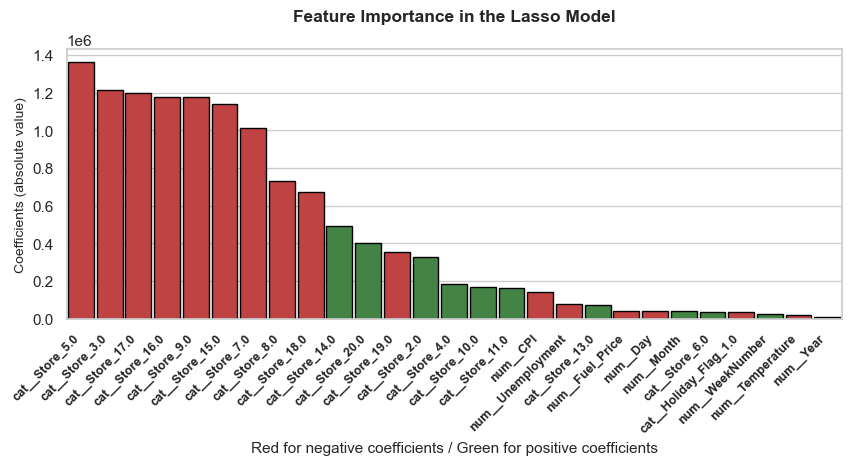

In [125]:
# See the feature importance for Lidge model

# Extarct feature names
feature_names_out = preprocessor.get_feature_names_out()
feature_names = [fname for fname in feature_names_out]
coefs = pd.DataFrame(index = feature_names, data = lasso.coef_.transpose(), columns=["coefficients"])

# Feature importance into a dataframe
feature_importance = coefs.sort_values(by='coefficients', ascending=False)

# Sorted by importance (using absolute values)
feature_importance_abs = abs(coefs).sort_values(by='coefficients', ascending=False)
feature_importance_abs = feature_importance_abs.transpose()
feature_importance_abs

# Colors green for positive importance / red for negative importance
negative_coefs = feature_importance[feature_importance['coefficients'] < 0]
colors = ['#d32f2f' if y in negative_coefs.index else '#388e3c' for y in feature_importance_abs.columns]

# Plot feature importance

sns.set(rc={'figure.figsize':(10, 3.5)}, style='whitegrid')
sns.barplot(data=feature_importance_abs, orient='v', palette=colors, width=0.9, edgecolor='black')

plt.title('Feature Importance in the Lasso Model', fontsize=12.5, pad=20, fontweight='bold')
plt.xlabel('Red for negative coefficients / Green for positive coefficients', fontsize=11)
plt.ylabel('Coefficients (absolute value)', fontsize=10)
plt.xticks(fontsize=9, fontweight='bold', rotation=45, ha='right')
plt.xticks(feature_importance_abs.columns, fontsize=9, fontweight='bold', rotation=45, ha='right')
plt.legend('', frameon=False)
plt.show()



##### The Ridge model performs worse than the baseline, while the Lasso model shows performance equivalent to the baseline. However, in the Lasso model, all feature importance is now attributed to the "Store" feature. It is notable that in both cases, only the "Store" feature retains significant importance. Let's have a look on the regularization hyperparameter to improve models performance.

# **6. Ridge and Lasso models : optimization of regularization hyperparameter**

In [126]:
# Gridsearch_CV to measure the best alpha for Ridge

# List of alphas between 0.05 and 2, range 0.05 (40 values)
alphas = [i / 100 for i in range(5, 201, 5)]

# Gridsearch_CV application (CV=5)
param_grid = {'alpha': alphas}
ridge_alpha = GridSearchCV(estimator=Ridge(), param_grid=param_grid, cv=5)
ridge_alpha.fit(X_train, Y_train)

print(ridge_alpha.best_params_)
print(ridge_alpha.best_score_)


{'alpha': 0.05}
0.9162832964855763


Text(0, 0.5, 'R² Score')

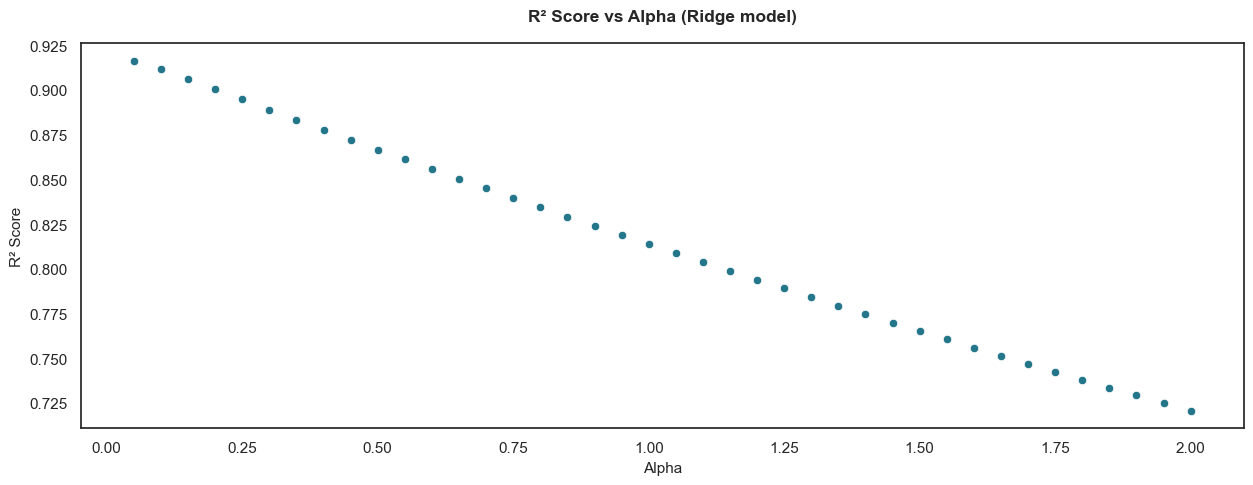

In [127]:
# Plot R² Score as a function of Alpha for Ridge

sns.set(rc={'figure.figsize': (15, 5)}, style='white')
colors = sns.color_palette("crest", as_cmap=True)

# Extract the mean test scores for each alpha value
mean_scores = ridge_alpha.cv_results_['mean_test_score']


# Plot the R^2 score as a function of alpha
plt.figure()
sns.scatterplot(x=alphas, y=mean_scores, color=colors(0.6))

plt.title('R² Score vs Alpha (Ridge model)', fontsize=12.5, pad=16, fontweight='bold')
plt.xlabel('Alpha', fontsize=11)
plt.ylabel('R² Score', fontsize=11)


In [128]:
# Application of the Best_Ridge model and scoring

best_ridge = Ridge(**ridge_alpha.best_params_)

best_ridge.fit(X_train, Y_train)

# Predictions on training and testing set
Y_train_pred = best_ridge.predict(X_train)
Y_test_pred = best_ridge.predict(X_test)

# Print R^2 scores
print("R2 score on training set : ", r2_score(Y_train, Y_train_pred))
print("R2 score on test set : ", r2_score(Y_test, Y_test_pred))

# Store baseline_results
best_ridge_dic = {'Model_Name' : 'Best_Ridge',
                'R²_Train' : round(r2_score(Y_train, Y_train_pred),3),
                'R²_Test' : round(r2_score(Y_test, Y_test_pred),3) }

# Add the results to the model_results DataFrame
model_results = update_model_results(model_results, best_ridge_dic)

# Display model_results to check the function
model_results

R2 score on training set :  0.9748474978380184
R2 score on test set :  0.9439757527554001


,Model_Name,R²_Train,R²_Test
0,Baseline_LogisticReg,0.976,0.938
1,Ridge,0.929,0.910
2,Lasso,0.976,0.939
3,Best_Ridge,0.975,0.944


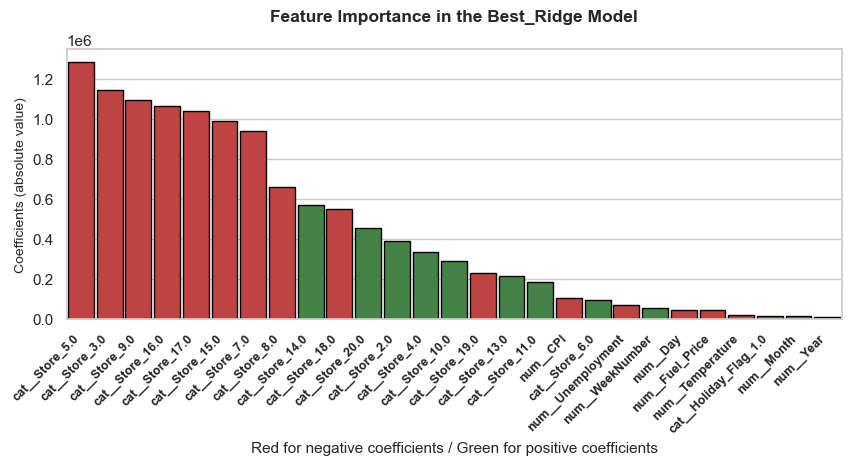

In [129]:
# See the feature importance for Best_Ridge model

# Extarct feature names
feature_names_out = preprocessor.get_feature_names_out()
feature_names = [fname for fname in feature_names_out]
coefs = pd.DataFrame(index = feature_names, data = best_ridge.coef_.transpose(), columns=["coefficients"])

# Feature importance into a dataframe
feature_importance = coefs.sort_values(by='coefficients', ascending=False)

# Sorted by importance (using absolute values)
feature_importance_abs = abs(coefs).sort_values(by='coefficients', ascending=False)
feature_importance_abs = feature_importance_abs.transpose()
feature_importance_abs

# Colors green for positive importance / red for negative importance
negative_coefs = feature_importance[feature_importance['coefficients'] < 0]
colors = ['#d32f2f' if y in negative_coefs.index else '#388e3c' for y in feature_importance_abs.columns]

# Plot feature importance

sns.set(rc={'figure.figsize':(10, 3.5)}, style='whitegrid')
sns.barplot(data=feature_importance_abs, orient='v', palette=colors, width=0.9, edgecolor='black')

plt.title('Feature Importance in the Best_Ridge Model', fontsize=12.5, pad=20, fontweight='bold')
plt.xlabel('Red for negative coefficients / Green for positive coefficients', fontsize=11)
plt.ylabel('Coefficients (absolute value)', fontsize=10)
plt.xticks(fontsize=9, fontweight='bold', rotation=45, ha='right')
plt.xticks(feature_importance_abs.columns, fontsize=9, fontweight='bold', rotation=45, ha='right')
plt.legend('', frameon=False)
plt.show()



In [130]:
# Gridsearch_CV to measure the best alpha for Lasso

# List of alphas between 10 and 1000, range 10 + alpha = 1 (101 values)
alphas = [1] + [i for i in range(10, 1010, 10)]

# Gridsearch_CV application (CV=5)
param_grid = {'alpha': alphas}
lasso_alpha = GridSearchCV(estimator=Lasso(), param_grid=param_grid, cv=5)
lasso_alpha.fit(X_train, Y_train)

print(lasso_alpha.best_params_)
print(lasso_alpha.best_score_)


{'alpha': 340}
0.9193660844756284


Text(0, 0.5, 'R² Score')

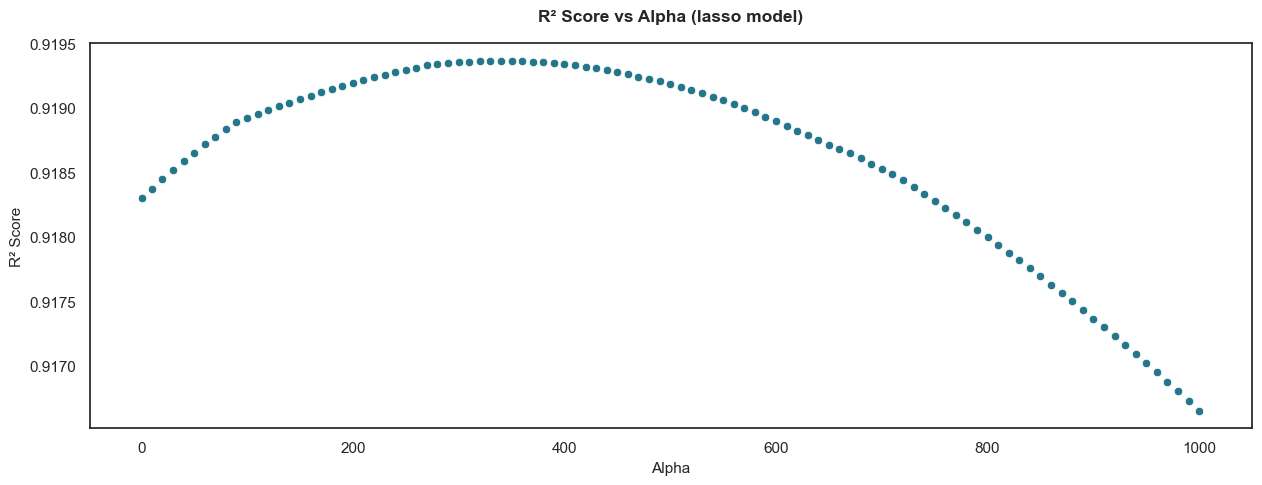

In [131]:
# Plot R² Score as a function of Alpha for Lasso

sns.set(rc={'figure.figsize': (15, 5)}, style='white')
colors = sns.color_palette("crest", as_cmap=True)

# Extract the mean test scores for each alpha value
mean_scores = lasso_alpha.cv_results_['mean_test_score']

# Plot the R^2 score as a function of alpha
plt.figure()
sns.scatterplot(x=alphas, y=mean_scores, color=colors(0.6))

plt.title('R² Score vs Alpha (lasso model)', fontsize=12.5, pad=16, fontweight='bold')
plt.xlabel('Alpha', fontsize=11)
plt.ylabel('R² Score', fontsize=11)

In [132]:
# Application of the Best_Lasso model and scoring

best_lasso = Lasso(**lasso_alpha.best_params_)

best_lasso.fit(X_train, Y_train)

# Predictions on training and testing set
Y_train_pred = best_lasso.predict(X_train)
Y_test_pred = best_lasso.predict(X_test)

# Print R^2 scores
print("R2 score on training set : ", r2_score(Y_train, Y_train_pred))
print("R2 score on test set : ", r2_score(Y_test, Y_test_pred))

# Store baseline_results
best_lasso_dic = {'Model_Name' : 'Best_RLasso',
                'R²_Train' : round(r2_score(Y_train, Y_train_pred),3),
                'R²_Test' : round(r2_score(Y_test, Y_test_pred),3) }

# Add the results to the model_results DataFrame
model_results = update_model_results(model_results, best_lasso_dic)

# Display model_results to check the function
model_results

R2 score on training set :  0.9754854418111867
R2 score on test set :  0.9415083858272355


,Model_Name,R²_Train,R²_Test
0,Baseline_LogisticReg,0.976,0.938
1,Ridge,0.929,0.910
2,Lasso,0.976,0.939
3,Best_Ridge,0.975,0.944
4,Best_RLasso,0.975,0.942


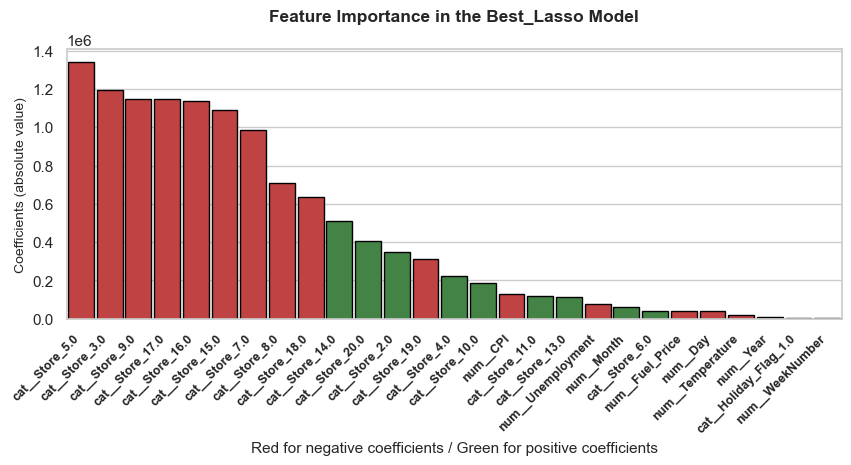

In [133]:
# See the feature importance for Best_Lasso model

# Extarct feature names
feature_names_out = preprocessor.get_feature_names_out()
feature_names = [fname for fname in feature_names_out]
coefs = pd.DataFrame(index = feature_names, data = best_lasso.coef_.transpose(), columns=["coefficients"])

# Feature importance into a dataframe
feature_importance = coefs.sort_values(by='coefficients', ascending=False)

# Sorted by importance (using absolute values)
feature_importance_abs = abs(coefs).sort_values(by='coefficients', ascending=False)
feature_importance_abs = feature_importance_abs.transpose()
feature_importance_abs

# Colors green for positive importance / red for negative importance
negative_coefs = feature_importance[feature_importance['coefficients'] < 0]
colors = ['#d32f2f' if y in negative_coefs.index else '#388e3c' for y in feature_importance_abs.columns]

# Plot feature importance

sns.set(rc={'figure.figsize':(10, 3.5)}, style='whitegrid')
sns.barplot(data=feature_importance_abs, orient='v', palette=colors, width=0.9, edgecolor='black')

plt.title('Feature Importance in the Best_Lasso Model', fontsize=12.5, pad=20, fontweight='bold')
plt.xlabel('Red for negative coefficients / Green for positive coefficients', fontsize=11)
plt.ylabel('Coefficients (absolute value)', fontsize=10)
plt.xticks(fontsize=9, fontweight='bold', rotation=45, ha='right')
plt.xticks(feature_importance_abs.columns, fontsize=9, fontweight='bold', rotation=45, ha='right')
plt.legend('', frameon=False)
plt.show()



# **7. Machine Learning conclusion and improvement axis**

##### **Model Results:**

- The best training R² performance is observed in the optimized Lasso and Ridge models, both exceeding 0.94. However, these models exhibit slight overfitting, as indicated by training R² values of 0.975.
- This minor overfitting does not appear to significantly impact the models' practical application.
- All models primarily rely on the "store" feature as the major contributor to feature importance. This confirms the weak relationship with other global economic and climatic variables (e.g., holiday_flag, temperature, fuel_price).
- Notably, the baseline model (logistic regression) demonstrates adequate performance compared to the optimized versions. It may be worth considering whether this lighter model would suffice for production purposes.

##### **Limitations:**

- Very limited data available (around a hundred rows had been used).
- Other types of data, more closely related to store-specific factors (e.g., promotions, sales area, store costs, margins), could be measured instead of global economic and climatic data to improve sales predictions, but also sales performances !
